Mounted at /content/drive
Loaded datasets: ['Stistical results-Unit root', 'Johanson and Julius', 'GOLD-Daily', 'Bitcoin-Daily', 'MSCI EMRT-Daily', 'GOLD-WEEKLY', 'Bitcoin-WEEKLY', 'MSCI EMRT-Weekly', 'GOLD-Monthly', 'Bitcoin-Monthly', 'MSCI EMRT-Monthly']

PROCESSING: GLD-Daily
Logistic Regression: 51.16%
Random Forest: 51.94%
XGBoost: 50.39%
LSTM: 49.22%

PROCESSING: GLD-3Day
Logistic Regression: 50.50%
Random Forest: 49.31%
XGBoost: 50.10%
LSTM: 50.10%

PROCESSING: GLD-5Day
Logistic Regression: 52.03%
Random Forest: 50.00%
XGBoost: 47.64%
LSTM: 52.03%

PROCESSING: GLD-Weekly
Logistic Regression: 55.03%
Random Forest: 54.50%
XGBoost: 53.97%


LSTM: 51.32%

PROCESSING: GLD-Biweekly
Logistic Regression: 50.54%
Random Forest: 61.29%
XGBoost: 54.84%


LSTM: 54.84%

PROCESSING: BTC-Daily
Logistic Regression: 50.29%
Random Forest: 51.94%
XGBoost: 51.55%
LSTM: 50.10%

PROCESSING: BTC-3Day
Logistic Regression: 48.91%
Random Forest: 50.30%
XGBoost: 52.87%
LSTM: 50.89%

PROCESSING: BTC-5Day
Logistic Regression: 44.26%
Random Forest: 45.27%
XGBoost: 51.69%
LSTM: 46.96%

PROCESSING: BTC-Weekly
Logistic Regression: 43.39%
Random Forest: 46.03%
XGBoost: 49.21%
LSTM: 48.68%

PROCESSING: BTC-Biweekly
Logistic Regression: 44.09%
Random Forest: 49.46%
XGBoost: 44.09%
LSTM: 46.24%

PROCESSING: MEM-Daily
Logistic Regression: 63.59%
Random Forest: 66.37%
XGBoost: 66.75%
LSTM: 52.47%

PROCESSING: MEM-3Day
Logistic Regression: 56.89%
Random Forest: 55.36%
XGBoost: 54.08%
LSTM: 44.39%

PROCESSING: MEM-5Day
Logistic Regression: 55.26%
Random Forest: 53.51%
XGBoost: 56.58%
LSTM: 56.14%

PROCESSING: MEM-Weekly
Logistic Regression: 56.43%
Random Forest: 59.29%
XGBoost: 62.86%
LSTM: 53.57%

PROCESSING: MEM-Biweekly
Logistic Regression: 49.28%
Random Forest:

Model            Naive Benchmark  Logistic Regression  Random Forest  XGBoost  \
Asset Timeframe                                                                 
BTC   3Day                  50.9                 48.9           50.3     52.9   
      5Day                  49.3                 44.3           45.3     51.7   
      Biweekly              54.8                 44.1           49.5     44.1   
      Daily                 51.8                 50.3           51.9     51.6   
      Weekly                46.6                 43.4           46.0     49.2   
GLD   3Day                  48.5                 50.5           49.3     50.1   
      5Day                  50.3                 52.0           50.0     47.6   
      Biweekly              48.4                 50.5           61.3     54.8   
      Daily                 48.9                 51.2           51.9     50.4   
      Weekly                55.0                 55.0           54.5     54.0   
MEM   3Day                  50.0                 56.9           55.4     54.1   
      5Day                  49.6                 55.3           53.5     56.6   
      Biweekly              42.0                 49.3           59.4     49.3   
      Daily                 49.9                 63.6           66.4     66.8   
      Weekly                49.3                 56.4           59.3     62.9   

Model            LSTM  Sample Size           Best Model  
Asset Timeframe                                          
BTC   3Day       50.9          505              XGBoost  
      5Day       47.0          296              XGBoost  
      Biweekly   46.2           93        Random Forest  
      Daily      50.1         1032        Random Forest  
      Weekly     48.7          189              XGBoost  
GLD   3Day       50.1          505  Logistic Regression  
      5Day       52.0          296  Logistic Regression  
      Biweekly   54.8           93        Random Forest  
      Daily      49.2         1032        Random Forest  
      Weekly     51.3          189  Logistic Regression  
MEM   3Day       44.4          392  Logistic Regression  
      5Day       56.1          228              XGBoost  
      Biweekly   43.5           69        Random Forest  
      Daily      52.5          791              XGBoost  
      Weekly     53.6          140              XGBoost

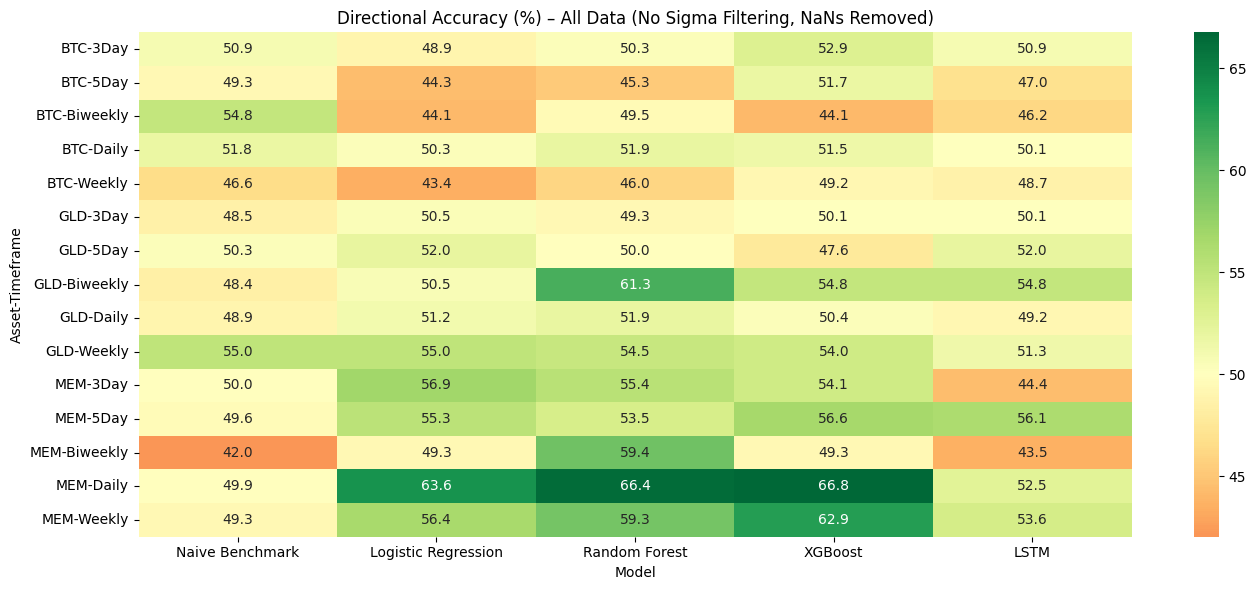

Results saved.


In [ ]:
# ========================
# 1. Setup and Data Loading
# ========================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Datasets/dataset.xlsx"
xls = pd.ExcelFile(file_path)
datasets = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in xls.sheet_names}
print("Loaded datasets:", list(datasets.keys()))

# ========================
# 2. Resampling Function (unchanged)
# ========================
def resample_daily_to_period(df, period_days, asset_prefix):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df.set_index('Date', inplace=True)

    if asset_prefix == 'GLD':
        spot_col, fut_col = 'GLDS', 'GLDF'
    elif asset_prefix == 'BTC':
        spot_col, fut_col = 'BTCS', 'BTCF'
    elif asset_prefix == 'MEM':
        spot_col, fut_col = 'MEMS', 'MEMF'
    else:
        raise ValueError("Unknown asset prefix")

    resampled = df[[spot_col, fut_col]].resample(f'{period_days}D').last().dropna()
    resampled[f'L{asset_prefix}S'] = np.log(resampled[spot_col])
    resampled[f'L{asset_prefix}F'] = np.log(resampled[fut_col])
    resampled[f'DL{asset_prefix}S'] = resampled[f'L{asset_prefix}S'].diff()
    resampled[f'DL{asset_prefix}F'] = resampled[f'L{asset_prefix}F'].diff()
    return resampled.reset_index()

# ========================
# 3. Feature Engineering (ETHICAL target: direction only)
# ========================
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def feature_engineering_ultimate(df, asset_prefix):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    if asset_prefix == 'GLD':
        spot_ret, log_spot, log_fut = 'DLGLDS', 'LGLDS', 'LGLDF'
    elif asset_prefix == 'BTC':
        spot_ret, log_spot, log_fut = 'DLBTCS', 'LBTCS', 'LBTCF'
    elif asset_prefix == 'MEM':
        spot_ret, log_spot, log_fut = 'DLMEMS', 'LMEMS', 'LMEMF'
    else:
        raise ValueError("Unknown asset prefix")

    # ----- ETHICAL TARGET: direction only, keep all data -----
    next_ret = df[spot_ret].shift(-1)
    df['Target'] = (next_ret > 0).astype(int)   # 1 = up, 0 = down

    # Volatility & rolling metrics (shifted to avoid look-ahead)
    df['Rolling_Std_20'] = df[spot_ret].rolling(20).std().shift(1)

    # Basis (cointegration)
    df['Basis'] = df[log_fut] - df[log_spot]
    df['Basis_Change'] = df['Basis'].diff()
    df['Zscore_Basis'] = (df['Basis'] - df['Basis'].rolling(20).mean()) / df['Basis'].rolling(20).std()

    # Lags and momentum
    df['Lag_1'] = df[spot_ret].shift(1)
    df['Lag_2'] = df[spot_ret].shift(2)
    df['Lag_3'] = df[spot_ret].shift(3)
    df['Momentum_5'] = df[spot_ret].rolling(5).sum()
    df['Momentum_10'] = df[spot_ret].rolling(10).sum()

    # Volatility features
    df['Volatility_7'] = df[spot_ret].rolling(7).std()
    df['Volatility_14'] = df[spot_ret].rolling(14).std()
    df['Vol_Ratio'] = df['Volatility_7'] / df['Volatility_14']
    df['Vol_of_Vol'] = df['Volatility_7'].rolling(7).std()

    # Futures returns
    df['Futures_Return'] = df[log_fut].diff()
    df['Fut_Lag1'] = df['Futures_Return'].shift(1)

    # Correlation / covariance
    df['Corr_20'] = df[spot_ret].rolling(20).corr(df['Futures_Return'])
    df['Cov_20'] = df[spot_ret].rolling(20).cov(df['Futures_Return'])

    # RSI and MACD
    df['RSI_14'] = compute_rsi(df[spot_ret], 14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = compute_macd(df[spot_ret])

    # Time dummies
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month
    dow_dummies = pd.get_dummies(df['DayOfWeek'], prefix='dow', drop_first=True)
    month_dummies = pd.get_dummies(df['Month'], prefix='month', drop_first=True)
    df = pd.concat([df, dow_dummies, month_dummies], axis=1)

    # Error correction term (ECT)
    df['ECT'] = df[log_spot] - df[log_fut]
    df['ECT_lag1'] = df['ECT'].shift(1)

    # Higher moments
    df['Return_Skew_20'] = df[spot_ret].rolling(20).skew()
    df['Return_Kurt_20'] = df[spot_ret].rolling(20).kurt()
    df['Pct_From_High_20'] = (df[log_spot] - df[log_spot].rolling(20).max()) / df[log_spot].rolling(20).std()
    df['Pct_From_Low_20'] = (df[log_spot] - df[log_spot].rolling(20).min()) / df[log_spot].rolling(20).std()

    # Interaction features
    df['Mom_Vol_Interaction'] = df['Momentum_5'] * df['Volatility_7']
    df['Basis_x_Vol'] = df['Basis'] * df['Volatility_7']
    df['Trend_Regime'] = (df['Momentum_5'] > 0).astype(int)

    # Acceleration
    df['Return_Accel'] = df[spot_ret].diff()
    df['Vol_Accel'] = df['Volatility_7'].diff()

    # Drop rows where target is NaN (only the last row)
    df = df.dropna(subset=['Target']).reset_index(drop=True)
    return df

# Base feature list
base_features = [
    'Basis', 'Basis_Change', 'Zscore_Basis',
    'Lag_1', 'Lag_2', 'Lag_3', 'Momentum_5', 'Momentum_10',
    'Volatility_7', 'Volatility_14', 'Vol_Ratio', 'Vol_of_Vol',
    'Futures_Return', 'Fut_Lag1',
    'Corr_20', 'Cov_20',
    'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist',
    'ECT', 'ECT_lag1',
    'Return_Skew_20', 'Return_Kurt_20',
    'Pct_From_High_20', 'Pct_From_Low_20',
    'Mom_Vol_Interaction', 'Basis_x_Vol', 'Trend_Regime',
    'Return_Accel', 'Vol_Accel'
]

# ========================
# 4. Models (including LSTM) with NaN handling
# ========================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

def walk_forward_tuned(data, feature_cols, model_name, window, retrain_freq, time_steps=5):
    # Ensure we only use features that exist in data
    avail_features = [f for f in feature_cols if f in data.columns]
    dummy_cols = [c for c in data.columns if c.startswith('dow_') or c.startswith('month_')]
    avail_features.extend(dummy_cols)

    # Drop rows with any NaN in features or target
    data_clean = data[avail_features + ['Target']].dropna().reset_index(drop=True)
    if len(data_clean) < window + 10:
        return 0.0, [], []  # Not enough data

    y_true, y_pred = [], []
    tscv = TimeSeriesSplit(n_splits=3)

    # LSTM specific
    scaler = None
    lstm_model = None

    for i in range(window, len(data_clean)):
        if (i - window) % retrain_freq == 0:
            train = data_clean.iloc[i-window:i]
            X_train = train[avail_features].values
            y_train = train['Target'].values

            if model_name == 'Random Forest':
                param_grid = {'n_estimators': [100, 200, 300],
                              'max_depth': [3, 5, 8, None],
                              'min_samples_split': [2, 5, 10]}
                model = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                                           param_grid, n_iter=10, cv=tscv, scoring='accuracy', random_state=42)
                model.fit(X_train, y_train)
                best_model = model.best_estimator_
            elif model_name == 'XGBoost':
                param_grid = {'n_estimators': [100, 200],
                              'max_depth': [3, 5, 7],
                              'learning_rate': [0.01, 0.05, 0.1],
                              'subsample': [0.7, 0.9, 1.0]}
                model = RandomizedSearchCV(XGBClassifier(random_state=42, verbosity=0),
                                           param_grid, n_iter=10, cv=tscv, scoring='accuracy', random_state=42)
                model.fit(X_train, y_train)
                best_model = model.best_estimator_
            elif model_name == 'Logistic Regression':
                best_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            elif model_name == 'LSTM':
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X_train)
                if len(X_scaled) <= time_steps:
                    lstm_model = None
                else:
                    X_seq, y_seq = create_sequences(X_scaled, y_train, time_steps)
                    lstm_model = Sequential([
                        Input(shape=(time_steps, len(avail_features))),
                        LSTM(16, return_sequences=False),
                        Dropout(0.3),
                        Dense(1, activation='sigmoid')
                    ])
                    lstm_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
                    early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
                    lstm_model.fit(X_seq, y_seq, epochs=30, batch_size=8, callbacks=[early_stop], verbose=0)
                best_model = 'LSTM'
            else:
                raise ValueError(f"Unknown model: {model_name}")

        X_test = data_clean.iloc[i:i+1][avail_features].values
        y_test = data_clean['Target'].iloc[i]
        y_true.append(y_test)

        if model_name == 'LSTM':
            if lstm_model is None or i < time_steps:
                y_pred.append(0)
            else:
                test_block = data_clean.iloc[i - time_steps : i][avail_features].values
                test_scaled = scaler.transform(test_block)
                X_test_seq = test_scaled.reshape(1, time_steps, len(avail_features))
                pred_prob = lstm_model.predict(X_test_seq, verbose=0)[0][0]
                y_pred.append(1 if pred_prob > 0.5 else 0)
        else:
            y_pred.append(best_model.predict(X_test)[0])

    return accuracy_score(y_true, y_pred) * 100, y_true, y_pred

# ========================
# 5. Master Configuration
# ========================
asset_sheet_map = {
    'GLD': {'daily': 'GOLD-Daily', 'weekly': 'GOLD-WEEKLY', 'monthly': 'GOLD-Monthly'},
    'BTC': {'daily': 'Bitcoin-Daily', 'weekly': 'Bitcoin-WEEKLY', 'monthly': 'Bitcoin-Monthly'},
    'MEM': {'daily': 'MSCI EMRT-Daily', 'weekly': 'MSCI EMRT-Weekly', 'monthly': 'MSCI EMRT-Monthly'}
}

configs = []
for asset_prefix, sheets in asset_sheet_map.items():
    configs.append((f'{asset_prefix}-Daily', asset_prefix, 252, 20, 'daily', sheets['daily'], 10))
    configs.append((f'{asset_prefix}-3Day', asset_prefix, 84, 10, '3D', sheets['daily'], 5))
    configs.append((f'{asset_prefix}-5Day', asset_prefix, 50, 5, '5D', sheets['daily'], 4))
    configs.append((f'{asset_prefix}-Weekly', asset_prefix, 52, 4, 'weekly', sheets['weekly'], 4))
    configs.append((f'{asset_prefix}-Biweekly', asset_prefix, 18, 2, '14D', sheets['daily'], 3))

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LSTM']
final_results = []

for sheet_label, asset_prefix, window, retrain_freq, freq_type, source_sheet, lstm_steps in configs:
    print(f"\n{'='*60}\nPROCESSING: {sheet_label}\n{'='*60}")
    try:
        if freq_type in ['3D', '5D', '14D']:
            period_days = 3 if freq_type == '3D' else (5 if freq_type == '5D' else 14)
            raw_df = datasets[source_sheet]
            df_proc = resample_daily_to_period(raw_df, period_days, asset_prefix)
            df_proc = feature_engineering_ultimate(df_proc, asset_prefix)
        else:
            raw_df = datasets[source_sheet]
            df_proc = feature_engineering_ultimate(raw_df, asset_prefix)

        # --- CRITICAL: Remove rows with NaN in any feature or target ---
        avail_features = [f for f in base_features if f in df_proc.columns]
        dummy_cols = [c for c in df_proc.columns if c.startswith('dow_') or c.startswith('month_')]
        all_features = avail_features + dummy_cols + ['Target']
        df_proc = df_proc[all_features].dropna().reset_index(drop=True)

        if len(df_proc) <= window:
            print(f"Skipping: only {len(df_proc)} rows after cleaning.")
            continue

        # Naive benchmark: predict same sign as previous return
        naive_pred = (df_proc['Lag_1'] > 0).astype(int).iloc[window:].values
        y_true_global = None

        for model_name in models:
            if model_name == 'LSTM' and len(df_proc) < window + lstm_steps + 20:
                print(f"Skipping LSTM for {sheet_label}: insufficient data.")
                continue

            acc, y_true, y_pred = walk_forward_tuned(
                df_proc, base_features, model_name, window, retrain_freq, time_steps=lstm_steps
            )
            if y_true_global is None:
                y_true_global = y_true
                naive_acc = accuracy_score(y_true, naive_pred) * 100
                final_results.append({
                    'Asset': asset_prefix,
                    'Timeframe': sheet_label.split('-')[1],
                    'Model': 'Naive Benchmark',
                    'Directional Acc (%)': round(naive_acc, 2),
                    'Sample Size': len(y_true)
                })
            final_results.append({
                'Asset': asset_prefix,
                'Timeframe': sheet_label.split('-')[1],
                'Model': model_name,
                'Directional Acc (%)': round(acc, 2),
                'Sample Size': len(y_true)
            })
            print(f"{model_name}: {acc:.2f}%")

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

# ========================
# 6. Final Results Table
# ========================
results_df = pd.DataFrame(final_results)
pivot = results_df.pivot_table(index=['Asset', 'Timeframe'], columns='Model', values='Directional Acc (%)')
col_order = ['Naive Benchmark', 'Logistic Regression', 'Random Forest', 'XGBoost', 'LSTM']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

sample_sizes = results_df.groupby(['Asset', 'Timeframe'])['Sample Size'].first()
pivot['Sample Size'] = sample_sizes

def get_best_model(row):
    ml_models = [c for c in row.index if c not in ['Naive Benchmark', 'Sample Size']]
    if len(ml_models) == 0:
        return 'N/A'
    return row[ml_models].idxmax()

pivot['Best Model'] = pivot.apply(get_best_model, axis=1)
final_cols = [c for c in pivot.columns if c != 'Best Model']
pivot = pivot[final_cols + ['Best Model']]

print("\n" + "*"*80)
print("FINAL PERFORMANCE MATRIX (ETHICAL: Directional Prediction, All Data, No NaNs)")
print("*"*80)
display(pivot.round(1))

def highlight_best_ml(row):
    ml_cols = [c for c in row.index if c not in ['Naive Benchmark', 'Sample Size', 'Best Model']]
    best_val = row[ml_cols].max() if len(ml_cols) > 0 else np.nan
    return ['background-color: #a8e6cf; font-weight: bold' if (col in ml_cols and row[col] == best_val) else '' for col in row.index]

styled = pivot.style.apply(highlight_best_ml, axis=1)
display(styled)

plt.figure(figsize=(14, 6))
heatmap_data = pivot.drop(columns=['Sample Size', 'Best Model'], errors='ignore')
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn", center=50)
plt.title("Directional Accuracy (%) – All Data (No Sigma Filtering, NaNs Removed)")
plt.tight_layout()
plt.show()

# Save results
results_df.to_csv('/content/drive/MyDrive/Dissertation/final_results_ethical.csv', index=False)
print("Results saved.")
